<a href="https://colab.research.google.com/github/romanahma/Machine-Learning-Project-/blob/main/Copy_of_Untitled16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Titanic Survival Prediction with Neural Networks

# ASHIR KHAN
#  F2022332006

In [ ]:
import pandas as pd;
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import numpy as np

In [ ]:
df = pd.read_csv('/content/titanic.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


Survived is the target.

Sex, Pclass, Embarked are categorical and need encoding.

Age, Fare are numerical and may have missing values.

Cabin has many missing values – we’ll likely drop it.

In [ ]:
df.shape

(418, 12)

df.sh

# **Data Preprocessing**

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

Drop Cabin due to too many missing values

In [ ]:
df = df.drop(columns=['Cabin'])

Drop rows with missing 'Embarked' values (only a few)

In [ ]:
df = df.dropna(subset=['Embarked'])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.shape

(418, 11)

d

# Feature Encoding

Label encode 'Sex' (male=1, female=0)

In [ ]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

One-hot encode 'Pclass' and 'Embarked', dropping the first category to avoid dummy trap

In [ ]:
df = pd.get_dummies(df, columns=['Pclass', 'Embarked'], drop_first=True)

Drop irrelevant columns

In [ ]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [ ]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,0,1,34.5,0,0,7.8292,False,True,True,False
1,1,0,47.0,1,0,7.0000,False,True,False,True
2,0,1,62.0,0,0,9.6875,True,False,True,False
3,0,1,27.0,0,0,8.6625,False,True,False,True
4,1,0,22.0,1,1,12.2875,False,True,False,True


# Feature Scaling

In [ ]:
scaler = StandardScaler()
numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare']

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Split the Dataset (Train/Test)

Define features (X) and label/target (y)

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

Split: 80% train, 20% validation

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Model Architecture

In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

## Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train and Validate the Model

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5631 - loss: 0.6763 - val_accuracy: 0.6190 - val_loss: 0.6235
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6228 - loss: 0.6518 - val_accuracy: 0.8214 - val_loss: 0.6045
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8203 - loss: 0.6244 - val_accuracy: 0.8095 - val_loss: 0.5855
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8060 - loss: 0.6029 - val_accuracy: 0.7738 - val_loss: 0.5667
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7919 - loss: 0.5736 - val_accuracy: 0.7500 - val_loss: 0.5492
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7003 - loss: 0.5732 - val_accuracy: 0.7262 - val_loss: 0.5333
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7202 - loss: 0.5519 - val_accuracy: 0.7262 - val_loss: 0.5179
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7274 - loss: 0.5177 - val_accuracy: 0.7262 - val_l

# Plot Training and Validation Accuracy & Loss

Plot accuracy

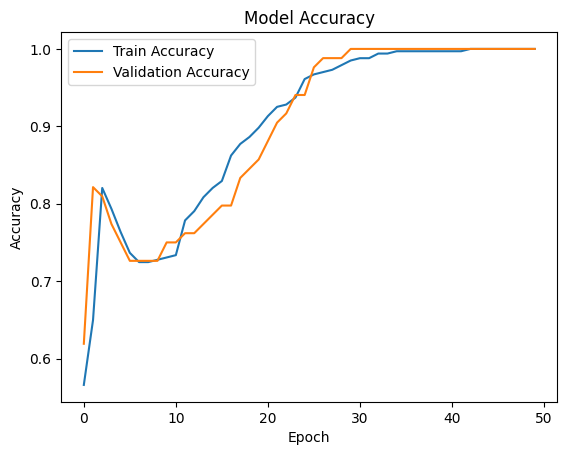

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Plot loss

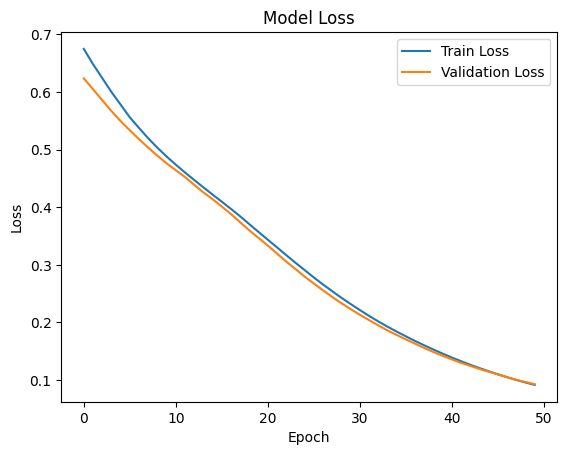

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the Final Model

In [ ]:
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0946
Validation Accuracy: 1.0000


In [ ]:
print(f"Final Validation Accuracy: {val_accuracy:.4f}")

Final Validation Accuracy: 1.0000


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict classes (0 or 1)
y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Confusion Matrix
print(confusion_matrix(y_val, y_pred_classes))

# Classification Report
print(classification_report(y_val, y_pred_classes))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[50  0]
 [ 0 34]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


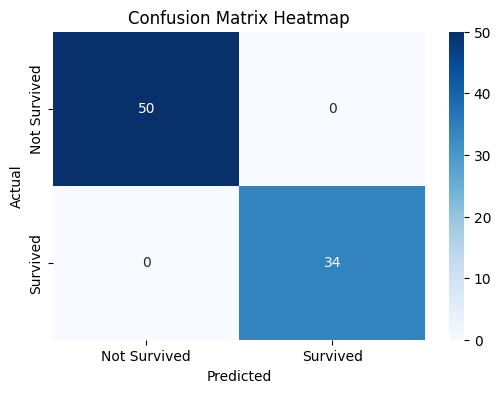

In [ ]:
# Get predicted classes (0 or 1)
y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred_classes)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [ ]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,0,1,0.386231,-0.499470,-0.400248,-0.497413,False,True,True,False
1,1,0,1.371370,0.616992,-0.400248,-0.512278,False,True,False,True
2,0,1,2.553537,-0.499470,-0.400248,-0.464100,True,False,True,False
3,0,1,-0.204852,-0.499470,-0.400248,-0.482475,False,True,False,True
4,1,0,-0.598908,0.616992,0.619896,-0.417492,False,True,False,True


In [ ]:
# Format: [Sex, Age, SibSp, Parch, Fare, Pclass_2, Pclass_3, Embarked_Q, Embarked_S]
sample_passenger = np.array([[0, 1, 0.386231, -0.499470, -0.400248, 0, 1, 0, 1]])

# Predict
prediction = model.predict(sample_passenger)

# Output
result = "Survived" if prediction > 0.5 else "Did Not Survive"
print(f"Prediction: {result} (Probability: {prediction[0][0]:.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction: Survived (Probability: 0.8039)
